# Zavšni projekat iz mašinskog učenja

*Milan Zeljković*

*Broj indeksa - 2020204144*

## Deo 1 - Linearna regresija

### Linearna regresija od nule

Problem:

Vaš zadatak je da implementirate linearnu regresiju od nule koristeći gradijentni spust. Treba da radite sa skupom podataka koji sadrži više karakteristika. Da bi zadatak bio zanimljiviji, uključićete polinomske karakteristike.

**Implementacija:**

* *Implementirati linearnu regresiju koristeći gradijentni spust.*

* *Primeniti polinomsku transformaciju stepena 2 na ulazne karakteristike. Ovo znači da treba uključiti kvadratne vrednosti ulaznih karakteristika u model.*

* *Koristiti srednju kvadratnu grešku (MSE) kao funkciju greške.*

* *Napisati kod za izračunavanje gradijenta i ažuriranje težina modela.*

**Vizuelizacija:**

* *Nacrtati grafikon funkcije greške (MSE) u zavisnosti od broja epoha tokom treniranja. Ovo će vam pomoći da vizualizujete kako model konvergira tokom iteracija.*

**Skup podataka:**

* *Možete generisati sintetičke podatke ili koristiti neki realni skup podataka sa više karakteristika.*

* *Ako koristite sintetičke podatke, generišite podatke gde je poznata prava veza, na primer: y= 3x_1 + 2x_2^2 + 4 za dve karakteristike x₁ i x₂.*

**Pitanja:**

* *Kako polinomske karakteristike utiču na model regresije?*

* *Šta se dešava sa funkcijom greške kada se stepen polinoma povećava?*

* *Kako izbor stope učenja utiče na konvergenciju modela tokom treniranja?*

#### Importovanje biblioteka

U ovom delu importujemo neophodne biblioteke za rad. Takođe se postavlja random.seed().

In [408]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [409]:
np.random.seed(42)

#### Generisanje sintetičkih podataka

Generisati podatke gde je poznata prava veza. Prava veza definisana je formulom:

$$y = 3x_1 + 2x_2^2 + 4 + \text{noise}$$

Na ovaj način dobija se nelinearnost, pa je potrebno koristiti polinomske karakteristike.

In [410]:
# Veličina skupa
m = 200

In [411]:
# Dve ulazne karakteristike, x1 i x2
x1 = np.random.uniform(-3, 3, m)
x2 = np.random.uniform(-3, 3, m)
x1.shape, x2.shape

((200,), (200,))

In [412]:
# noise - šum
noise = np.random.randn(m)
noise.shape

(200,)

#### Hipoteza

$$y = 3x_1 + 2x_2^2 + 4 + \text{noise}$$

In [413]:
y = 3*x1 + 2 * (x2 ** 2) + 4 + noise

#### Formatiranje matrice ulaznih podataka

Ulazne karakteristike se spajaju u jednu matricu oblika:

$$X = [x_1, x_2]$$

Svaki red predstavlja jedan primer (sample), dok kolone predstavljaju karakteristike (feature).

In [414]:
"""
  Ovo je moguće uraditi na više načina:
    1. np.column_stack((x1, x2)) - najjednostavniji način
    2. np.c_[x1, x2] - isto kao i ovo gore, samo nije metoda, nego property
    3. np.hstack - horizontalni stack, pa zahteva reshape da bih prebacilo u 2D
    4. np.concatenate - praktično radi isto što i np.hstack, takođe mora da se uradi reshape
"""

X_start = np.hstack((x1.reshape(-1, 1), x2.reshape(-1, 1)))
print(f"Ispis prvih par redova X matrice:\n\n{X[:5]}")
print(f"\nPrikaz dimenzija X matrice, očekivan rezultat je 200 x 2, a stvarna dimenzija je: {X_start.shape}")

Ispis prvih par redova X matrice:

[[ 1.         -0.37213971  0.47099449]
 [ 1.          1.58661523 -1.43784301]
 [ 1.          0.84305607 -1.17271371]
 [ 1.          0.38977043  1.34869148]
 [ 1.         -1.11502273  0.34917953]]

Prikaz dimenzija X matrice, očekivan rezultat je 200 x 2, a stvarna dimenzija je: (200, 2)


#### Standardizacija podataka

Kod gradient descent algoritma, standardizacija je često bolja zato što:

* Gradijent se stabilnije računa
* Feature-i imaju sličnu skalu
* Optimizacija brže konvergira


In [415]:
def standardize(X):
  mean = np.mean(X, axis=0) # Uzima srednju vrednost po svakoj koloni
  std = np.std(X, axis=0) # Uzima standardnu devijaciju po svakoj koloni

  X_scaled = (X - mean) / std
  return X_scaled, mean, std

In [416]:
X_scaled, X_mean, X_std = standardize(X_start)

#### Dodavanje bias-a

Bias predstavlja slobodan član modela, i omogućava da funkcija ne mora prolaziti kroz koordinatni početak. Dodaje se kao kolona jedinica na početak matrice ulaznih karakteristika (feature-a).
Bias se dodaje nakon standardizacije, jer je on kolona u kojoj se nalaze samo jedinice, pa sama standardizacija nema nikakvog efekta na njega, pošto su svi elementi niza isti, nema nikakve varijacije, pa bi i standardna devijacija bila 0, a to bi izazvalo problem pri standardizaciji zbog deljenja sa 0.

In [417]:
def add_bias(X):
  m = X.shape[0] # Uzima koliko samplova ima u glavnoj matrici
  ones = np.ones((m, 1))
  return np.hstack((ones, X))

In [418]:
X = add_bias(X_scaled)
print(f"Nakon dodate kolone bias:\n\n{X[:5]}")
print(f"\n Oblik matrice: {X.shape}")

Nakon dodate kolone bias:

[[ 1.         -0.37213971  0.47099449]
 [ 1.          1.58661523 -1.43784301]
 [ 1.          0.84305607 -1.17271371]
 [ 1.          0.38977043  1.34869148]
 [ 1.         -1.11502273  0.34917953]]

 Oblik matrice: (200, 3)


#### Implementacija funkcije predikcije

In [419]:
def predict_linear(X, theta):
  return X @ theta # matricno množenje, moglo je i sa dot

In [420]:
# Nakon dodavanja bias-a na standardizovanu matricu, dimenzija se promenila u 200 x 3
# Da bi matrica X mogla da se pomnoži sa inicijalnom matricom theta, dimenzije moraju da se poklapaju
theta_test = np.zeros(X.shape[1])
theta_test.shape

(3,)

In [421]:
y_predict_test = predict_linear(X, theta_test)
print(y_predict_test[:5])

[0. 0. 0. 0. 0.]


#### Funkcija greške (MSE)


$$MSE = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$


In [422]:
def mse(y_true, y_predict):
  m = len(y_true)
  return (1/m) * np.sum((y_predict - y_true)**2)

In [423]:
theta_test = np.zeros(X.shape[1])
y_predict_test = predict_linear(X, theta_test)
loss_test = mse(y, y_predict_test)
print(f"Inicijalna MSE: {loss_test}, bez optimizovanih vrednosti theta.")

Inicijalna MSE: 150.00555079975152, bez optimizovanih vrednosti theta.


#### Računanje gradijenta

Gradijent funkcije greške određuje smer i intenzitet promene parametara modela.
Za linearnu regresiju:

$$\nabla J(\theta)=\frac{2}{m}X^T(\hat{y}-y)$$

In [424]:
def compute_gradient_linear(X, y_real, y_predicted):
  m = len(y_real)
  gradient = (2/m) * (X.T @ (y_predicted - y_real))
  return gradient

In [425]:
gradient_test = compute_gradient_linear(X, y, y_predict_test)

print(gradient_test)
print(gradient_test.shape)

[-19.71917314  -9.16908781   1.59951042]
(3,)


#### Gradient descent

Gradient descent iterativno ažurira parametre modela kako bi minimizovao funkciju greške.

U svakoj epohi, vrši se:


1.   Predikcija
2.   Računanje MSE
3.   Računanje gradijenta
4.   Ažuriranje težina ($\theta$)

Ažuriranje se vrši formulom:

$$\theta := \theta - \alpha \nabla J(\theta)$$

Gde je:
- $\alpha$ - stopa učenja
- $\nabla J(\theta)\$ gradijent funkcije greške

In [426]:
def gradient_descent(X, y, predict_function, loss_function, gradient_function, learning_rate=0.01, epochs=1000):
  n_features = X.shape[1]

  theta = np.zeros(n_features)

  loss_history = []

  for epoch in range(epochs):
    y_predict = predict_function(X, theta)
    loss = loss_function(y, y_predict)
    gradient = gradient_function(X, y, y_predict)
    theta = theta - learning_rate * gradient # Model ovde uči
    loss_history.append(loss)

  return theta, loss_history

#### Treniranje modela

In [427]:
theta_linear, loss_history_linear = gradient_descent(X, y, predict_linear, mse, compute_gradient_linear, learning_rate=0.01, epochs=2000)

In [428]:
final_predictions = predict_linear(X, theta_linear)
final_mse = mse(y, final_predictions)

print(f"Naučene težine:\n\n{theta_linear}\n")
print(f"Finalni MSE: {final_mse}")

Naučene težine:

[ 9.85958657  4.56634188 -0.67697945]

Finalni MSE: 31.31809075312697


#### Vizuelizacija funkcije greške

Grafikon prikazuje promenu MSE funkcije greške kroz epohe tokom treniranja modela. Ako greška opada, model uspešno konvergira ka minimumu.

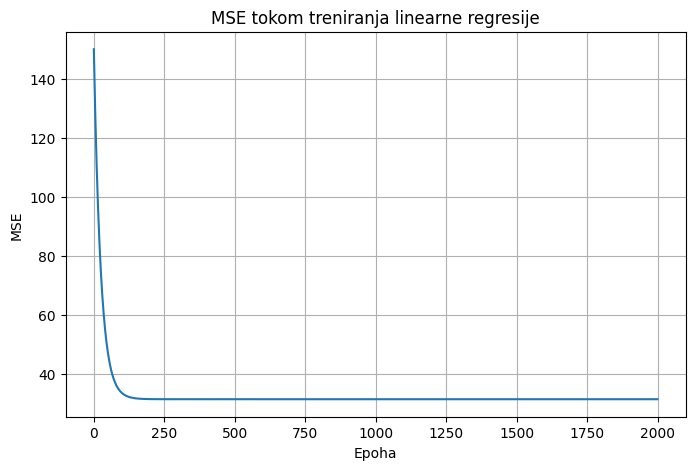

In [429]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_linear)

plt.xlabel("Epoha")
plt.ylabel("MSE")
plt.title("MSE tokom treniranja linearne regresije")
plt.grid(True)

In [430]:
from ipywidgets.widgets.widget_int import IntSlider
@widgets.interact(
    learning_rate = widgets.FloatSlider(value=0.01, min=0.0001, max=0.3,  step=0.0001, readout_format='.4f'),
    epochs        = widgets.IntSlider  (value=2000, min=10,    max=3000, step=10)
)
def plot_mse(learning_rate, epochs):
    _, loss_history = gradient_descent(X, y, predict_linear, mse, compute_gradient_linear, learning_rate=learning_rate, epochs=epochs)

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel("Epoha")
    plt.ylabel("MSE")
    plt.title(f"Learning rate={learning_rate} | Epohe={epochs}")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='learning_rate', max=0.3, min=0.0001, readout_format…

### Polinomijalna transformacija stepena 2

Hipoteza:
$$y = 3x_1 + 2x_2^2 + 4 + \text{noise}$$

Pošto $y$ zavisi od kvadratnog člana $x_2^2$, uvodi se polinomska transformacija stepena 2.



Za dve ulazne karakteristike $x_1$ i $x_2$, formiraju se sledeće nove karakteristike:

- $x_1$
- $x_2$
- $x_1^2$
- $x_2^2$
- $x_1x_2$

In [431]:
# def polynomial_transformation(X):
#   x1 = X[:, 0]
#   x2 = X[:, 1]

#   return np.column_stack((x1, x2, x1**2, x2**2, x1 * x2))

# def polynomial_transformation(X, degree=2):
#     columns = []

#     for d in range(degree):
#         for i in range(X.shape[1]):
#             columns.append(X[:, i]**(d + 1))

#     return np.column_stack(columns)

In [432]:
from itertools import combinations_with_replacement

def polynomial_transformation(X, degree=2):
    columns = []
    n_features = X.shape[1]

    for d in range(1, degree + 1):
        for combination in combinations_with_replacement(range(n_features), d):
            column = np.ones(X.shape[0])
            for i in combination:
                column *= X[:, i]
            columns.append(column)

    return np.column_stack(columns)

In [433]:
X_poly = polynomial_transformation(X_start)
print(f"Prvih 5 redova X_poly:\n\n{X_poly[:5]}\n")
print(f"Oblik matrice X_poly: {X_poly.shape}")

Prvih 5 redova X_poly:

[[-0.75275929  0.85218988  0.56664654 -0.64149384  0.72622759]
 [ 2.70428584 -2.49516021  7.3131619  -6.74762642  6.22582447]
 [ 1.39196365 -2.03022772  1.93756281 -2.82600318  4.12182458]
 [ 0.59195091  2.39132513  0.35040587  1.41554708  5.71843588]
 [-2.06388816  0.63857436  4.25963433 -1.31794605  0.40777721]]

Oblik matrice X_poly: (200, 5)


#### Standardizacija polinomskih feature-a

Pošto polinomski feature-i mogu imati veće vrednosti od originalnih ulaza, potrebno ih je standardizovati pre treniranja modela.

Ovaj korak omogućava stabilniju i bržu konvergenciju gradient descent-a.

In [434]:
X_poly_scaled, X_poly_mean, X_poly_std = standardize(X_poly)
print(f"Prvih 5 redova standardizovanih polinomskih feature-a:\n\n{X_poly_scaled[:5]}\n")
print(f"Oblik matrice X_poly_scaled: {X_poly_scaled.shape}")

Prvih 5 redova standardizovanih polinomskih feature-a:

[[-0.37213971  0.47099449 -0.97737975 -0.17869967 -0.84920702]
 [ 1.58661523 -1.43784301  1.60087943 -2.14207278  1.13849337]
 [ 0.84305607 -1.17271371 -0.45346818 -0.88110939  0.37805192]
 [ 0.38977043  1.34869148 -1.06001863  0.48272371  0.95510965]
 [-1.11502273  0.34917953  0.43393842 -0.39620691 -0.96430345]]

Oblik matrice X_poly_scaled: (200, 5)


#### Dodavanje bias-a

In [435]:
X_poly_final = add_bias(X_poly_scaled)
print(f"Prvih 5 redova sa dodatom bias kolonom:\n\n{X_poly_final[:5]}\n")
print(f"Oblik matrice X_poly_final: {X_poly_final.shape}")

Prvih 5 redova sa dodatom bias kolonom:

[[ 1.         -0.37213971  0.47099449 -0.97737975 -0.17869967 -0.84920702]
 [ 1.          1.58661523 -1.43784301  1.60087943 -2.14207278  1.13849337]
 [ 1.          0.84305607 -1.17271371 -0.45346818 -0.88110939  0.37805192]
 [ 1.          0.38977043  1.34869148 -1.06001863  0.48272371  0.95510965]
 [ 1.         -1.11502273  0.34917953  0.43393842 -0.39620691 -0.96430345]]

Oblik matrice X_poly_final: (200, 6)


#### Treniranje polinomijalnog modela

In [436]:
theta_poly, loss_history_poly = gradient_descent(X_poly_final, y, predict_linear, mse, compute_gradient_linear, learning_rate=0.01, epochs=2000)

In [437]:
final_predictions_poly = predict_linear(X_poly_final, theta_poly)
final_mse_poly = mse(y, final_predictions_poly)

print(f"Naučene težine:\n\n{theta_poly}\n")
print(f"Finalni MSE: {final_mse_poly}")

Naučene težine:

[ 9.85958657e+00  5.30066415e+00 -5.73391121e-02 -1.45808449e-01
 -7.86950463e-03  5.59156550e+00]

Finalni MSE: 0.9436975475740262


In [473]:
@widgets.interact(
    learning_rate = widgets.FloatSlider(value=0.01, min=0.0001, max=0.3,  step=0.0001, readout_format='.4f'),
    epochs        = widgets.IntSlider  (value=2000, min=10,    max=3000, step=10)
)
def plot_mse(learning_rate, epochs):
    _, loss_history = gradient_descent(X_poly_final, y, predict_linear, mse, compute_gradient_linear, learning_rate=learning_rate, epochs=epochs)

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel("Epoha")
    plt.ylabel("MSE")
    plt.title(f"Learning rate={learning_rate} | Epohe={epochs}")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='learning_rate', max=0.3, min=0.0001, readout_format…

### Poređenje performansi linearnog i polinomijalnog modela

Poredimo vrednost MSE za:
* osnovni linearni model
* model sa polinomskim karakteristikama stepena 2

Manja vrednost MSE ukazuje na bolju aproksimaciju stvarne funkcije.

In [439]:
print(f"MSE osnovnog linearnog modela: {final_mse}")
print(f"MSE polinomijalnog modela drugog stepena: {final_mse_poly}")

MSE osnovnog linearnog modela: 31.31809075312697
MSE polinomijalnog modela drugog stepena: 0.9436975475740262


### Odgovori na pitanja

**Pitanje:** *Kako polinomske karakteristike utiču na model regresije?*

**Odgovor:** *Polinomske karakteristike omogućavaju da se opišu nelinearni odnosi između ulaznih podataka i izlaza.*



---


**Pitanje:** *Šta se dešava sa funkcijom greške kada se stepen polinoma povećava?*

**Odgovor:** *Povećanjem stepena polinoma model dobija više karakteristika i postaje fleksibilniji.
To obično dovodi do smanjenja greške na trening podacima, jer model može preciznije da aproksimira odnos između ulaza i izlaza.
Međutim, prevelik stepen polinoma može dovesti do overfitting-a, odnosno situacije kada model previše prilagodi trening podatke i slabije generalizuje nove podatke.
U ovom primeru polinomijalna transformacija drugog stepena daje bolji rezultat od osnovnog linearnog modela, jer odgovara stvarnoj strukturi podataka.*


---


**Pitanje:** *Kako izbor stope učenja utiče na konvergenciju modela tokom treniranja?*

**Odgovor:** *Stopa učenja određuje veličinu koraka kojim se parametri modela ažuriraju tokom gradijentnog spusta.*
*Ako je stopa učenja previše mala:*
* *model konvergira veoma sporo*
* *potrebno je više epoha*

*Ako je stopa učenja prevelika:*
* *model može preskakati minimum*
* *funkcija greške može oscilovati ili rasti*

*U ovom projektu korišćena je vrednost learning rate = 0.01, koja omogućava stabilno opadanje MSE kroz epohe i uspešnu konvergenciju modela.*

## Deo 2 - Algoritam klasifikacije

**Problem:**

Vaš zadatak je da implementirate logističku regresiju od nule za binarni klasifikacioni problem. Ponovo ćete koristiti više karakteristika i polinomsku transformaciju stepena 3 na ulazne podatke.

**Implementacija:**

* *Implementirati logističku regresiju koristeći gradijentni spust.*

* *Primeniti polinomsku transformaciju stepena 3 na ulazne karakteristike.*

* *Koristiti binarni unakrsni entropijski gubitak (binary cross-entropy) kao funkciju greške.*

* *Implementirati računanje gradijenta za težine i bias.*

**Vizuelizacija:**

* *Nacrtati grafikon funkcije greške (binary cross-entropy) u zavisnosti od broja epoha kako biste vizualizovali konvergenciju modela logističke regresije.*

**Skup podataka:**

* *Možete koristiti sintetičke podatke, gde su prave klase binarne (0 ili 1), ili neki postojeći binarni klasifikacioni skup podataka (npr. Iris dataset, ali uzimajući u obzir samo dve klase).*

**Pitanja:**

* *Objasnite koncept logističke funkcije (sigmoid) i kako ona mapira ulaze u verovatnoće.*

* *Kako regularizacija (L1 ili L2) utiče na treniranje logističke regresije? Implementirati je ako je moguće.*

* *Koji izazovi se javljaju pri korišćenju polinomskih karakteristika u klasifikaciji i kako ih možete rešiti?*

### Učitavanje Banknote Authentication dataset-a

Za klasifikacioni problem, koristi se Banknote Authentication dataset iz UCI Machine Learning Repository, koji sadrži feature izvučene iz slika pravih i falsifikovanih novčanica. Dataset sadrži 1372 sample-a i 4 feature-a koje su izvučene iz slika novčanica pomoću wavelet transformacije.

Cilj je klasifikovati novčanicu kao:
* 0 - prava (genuine)
* 1 - falsifikovana (forged)

In [440]:
import pandas as pd

data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt", header=None)

data.columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

In [441]:
data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


### Eksploratorna data analiza (EDA)

Pre implementacije modela potrebno je analizirati osnovne karakteristike dataset-a:

* broj samplova i atributa
* tipove podataka
* postojanje nedostajućih vrednosti
* osnovne statističke osobine karakteristika
* raspodelu klasa

In [442]:
# Prikaz osnovnih informacija
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [443]:
# Provera po svakoj koloni (atributu, feature-u) da li postoje null vrednosti
data.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [444]:
# Iz ovoga se može videti da feature-i imaju različite skale
data.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [445]:
# Raspodela klasa
data["class"].value_counts()

,count
class,
0,762
1,610


Text(0, 0.5, 'Broj uzoraka')

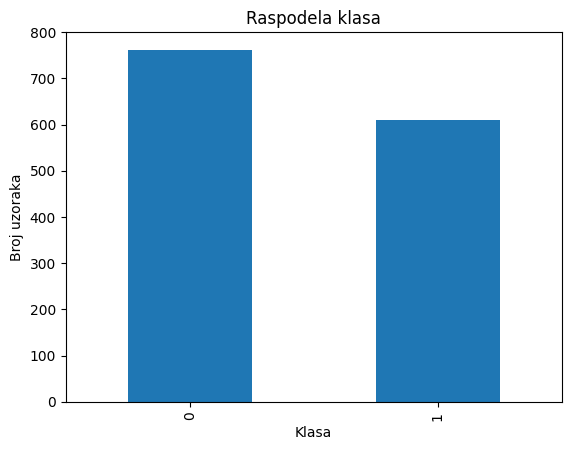

In [446]:
# Vizuelni prikaz raspodele klasa

data["class"].value_counts().plot(kind="bar")

plt.title("Raspodela klasa")
plt.xlabel("Klasa")
plt.ylabel("Broj uzoraka")

In [447]:
# Korelacija feature-a
data.corr()

,variance,skewness,curtosis,entropy,class
variance,1.000000,0.264026,-0.380850,0.276817,-0.724843
skewness,0.264026,1.000000,-0.786895,-0.526321,-0.444688
curtosis,-0.380850,-0.786895,1.000000,0.318841,0.155883
entropy,0.276817,-0.526321,0.318841,1.000000,-0.023424
class,-0.724843,-0.444688,0.155883,-0.023424,1.000000


### Razdvajanje ulaznih feature-a i targeta

In [448]:
# Uklanjamo "class" kolonu, da ne bi modelu dali odgovore unapred
# Values pretvara DataFrame u NumPy matricu
features_cls = data.drop("class", axis=1).values

In [449]:
target_cls = data["class"].values

In [450]:
print(f"Oblik matrice feature-a: {features_cls.shape}")
print(f"Oblik matrice target-a: {target_cls.shape}")

Oblik matrice feature-a: (1372, 4)
Oblik matrice target-a: (1372,)


In [451]:
print(f"Prvih 5 redova feature-a:\n\n{features_cls[:5]}\n")
print(f"Prvih 5 redova target-a:\n\n{target_cls[:5]}\n")

Prvih 5 redova feature-a:

[[ 3.6216   8.6661  -2.8073  -0.44699]
 [ 4.5459   8.1674  -2.4586  -1.4621 ]
 [ 3.866   -2.6383   1.9242   0.10645]
 [ 3.4566   9.5228  -4.0112  -3.5944 ]
 [ 0.32924 -4.4552   4.5718  -0.9888 ]]

Prvih 5 redova target-a:

[0 0 0 0 0]



### Standardizacija podataka

Dataset ne sadrži nedostajuće vrednosti, sve karakteristike su numeričkog tipa i pogodne su za logističke regresije nakon standardizacije, pošto su vrednosti feature-a različitog ranga. Kod gradient descent-a, feature-i sa većim vrednostima dominira, a to znači:

* model teže uči
* sporije konvergira (ide po elipsama, cik-cak)
* može biti nestabilan

In [452]:
features_cls_scaled, features_cls_mean, features_cls_std = standardize(features_cls)

In [453]:
print(f"Nakon standardizacije:\n\n{features_cls_scaled[:5]}")

Nakon standardizacije:

[[ 1.12180565  1.14945512 -0.97597007  0.35456135]
 [ 1.44706568  1.06445293 -0.89503626 -0.12876744]
 [ 1.20780971 -0.77735215  0.12221838  0.61807317]
 [ 1.06374236  1.29547754 -1.25539712 -1.14402883]
 [-0.03677175 -1.0870383   0.73673042  0.09658697]]


In [454]:
features_cls_scaled.shape

(1372, 4)

In [455]:
"""
  Potvrda da je standardizacija uspela je tako što se može proveriti:
    1. Srednja vrednost - nakon standardizacije treba da bude približno 0
    2. Standardna devijacija - nakon standardizacije treba da bude 1
"""
print(f"Provera srednjih vrednosti:\n{np.mean(features_cls_scaled, axis=0)}")
print(f"Provera standardnih devijacija:\n{np.std(features_cls_scaled, axis=0)}")

Provera srednjih vrednosti:
[ 0.00000000e+00  4.14310633e-17  1.03577658e-17 -4.91993877e-17]
Provera standardnih devijacija:
[1. 1. 1. 1.]


### Polinomijalna transformacija stepena 3

In [456]:
features_cls_poly = polynomial_transformation(features_cls_scaled, degree=3)

In [457]:
print(f"Prvih 5 redova feature-a nakon polinomijalne transformacije:\n\n{features_cls_poly[:5]}\n")
print(f"Shape: {features_cls_poly.shape}")

Prvih 5 redova feature-a nakon polinomijalne transformacije:

[[ 1.12180565e+00  1.14945512e+00 -9.75970069e-01  3.54561347e-01
   1.25844792e+00  1.28946526e+00 -1.09484874e+00  3.97748923e-01
   1.32124708e+00 -1.12183380e+00  4.07552358e-01  9.52517575e-01
  -3.46041262e-01  1.25713749e-01  1.41173399e+00  1.44652941e+00
  -1.22820750e+00  4.46196990e-01  1.48218245e+00 -1.25847949e+00
   4.57194538e-01  1.06853960e+00 -3.88191044e-01  1.41026394e-01
   1.51871423e+00 -1.28949761e+00  4.68463146e-01  1.09487621e+00
  -3.97758902e-01  1.44502313e-01 -9.29628643e-01  3.37725915e-01
  -1.22692856e-01  4.45732362e-02]
 [ 1.44706568e+00  1.06445293e+00 -8.95036261e-01 -1.28767444e-01
   2.09399907e+00  1.54033330e+00 -1.29517625e+00 -1.86334949e-01
   1.13306005e+00 -9.52723972e-01 -1.37066884e-01  8.01089908e-01
   1.15251532e-01  1.65810547e-02  3.03015418e+00  2.22896345e+00
  -1.87420510e+00 -2.69638909e-01  1.63961230e+00 -1.37865416e+00
  -1.98344783e-01  1.15922971e+00  1.66776536

### Dodavanje bias-a

In [458]:
features_cls_final = add_bias(features_cls_poly)
print(f"Oblik matrice nakon dodavanja bias-a: {features_cls_final.shape}")

Oblik matrice nakon dodavanja bias-a: (1372, 35)


### Sigmoid funkcija

Logistička regresija koristi sigmoid funkciju kako bi linearni izlaz pretvorila u verovatnoću za pripadnost nekoj klasi.

In [459]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [460]:
# Test da Sigmoid radi kako treba
sigmoid(0)

np.float64(0.5)

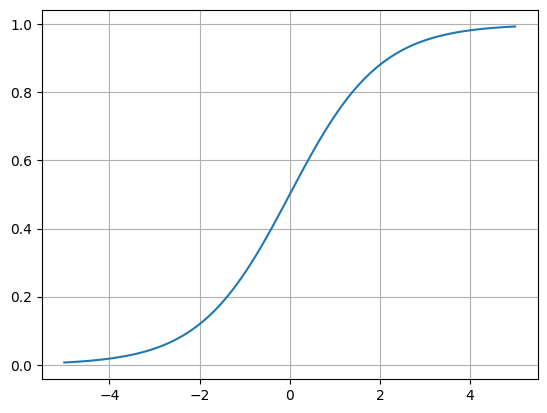

In [461]:
plt.plot(np.linspace(-5, 5, 100), sigmoid(np.linspace(-5, 5, 100)))
plt.grid(True)

In [462]:
theta_cls = np.zeros(features_cls_final.shape[1])

In [463]:
# Pošto su sve thete 0, model ništa nije naučio, u suštini svi izlazi će biti 0.5
test = sigmoid(predict_linear(features_cls_final, theta_cls))
print(test[:5])

[0.5 0.5 0.5 0.5 0.5]


In [464]:
def predict_logistic(X, theta):
  z = X @ theta
  return sigmoid(z)

### Binary cross-entropy

Za logističku regresiju koristi se binary cross-entropy funkcija greške. Ona meri razliku između stvarnih klasa i predviđenih verovatnoća.

In [465]:
def binary_cross_entropy(y_true, y_predict):
  y_predict = np.clip(y_predict, 1e-15, 1 - 1e-15)  # izbjegavamo log(0) pošto to teži beskonačnosti
  return -np.mean(y_true * np.log(y_predict) + (1 - y_true) * np.log(1 - y_predict))

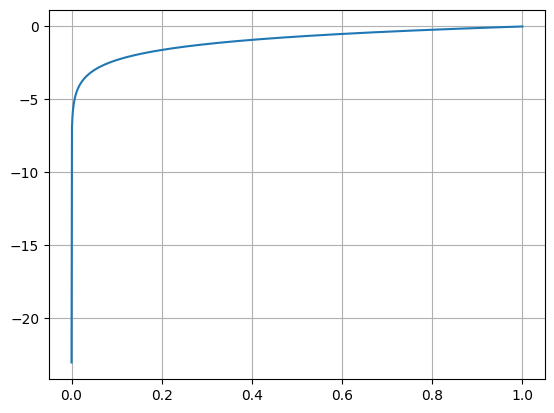

In [466]:
# Razlog zašto se koristi np.clip
log_x = np.linspace(1e-10, 1, 1000)
log_y = np.log(log_x)

plt.plot(log_x, log_y)
plt.grid(True)

In [467]:
# Kada model ne zna ništa, ovo je uvek početna vrednost loss funkcije
loss = binary_cross_entropy(target_cls, test)
loss

np.float64(0.6931471805599454)

### Računanje gradijenta

In [468]:
def compute_gradient_logistic(X, y_real, y_predicted):
  m = len(y_real)
  gradient = (1/m) * (X.T @ (y_predicted - y_real))
  return gradient

### Treniranje logističke regresije gradient descent-om

Kao i kod linearne regresije, ovaj model radi isto. Trenira se iterativno kroz epohe. U svakoj epohi:
* računa se predikcija
* računa se binary cross-entropy greška
* računa se gradijent
* ažuriraju se parametri modela

In [469]:
theta_logistic, loss_history_logistic = gradient_descent(
    features_cls_final,
    target_cls,
    predict_function=predict_logistic,
    loss_function=binary_cross_entropy,
    gradient_function=compute_gradient_logistic,
    learning_rate=0.01,
    epochs=2000
)

### Vizuelizacija funkcije greške

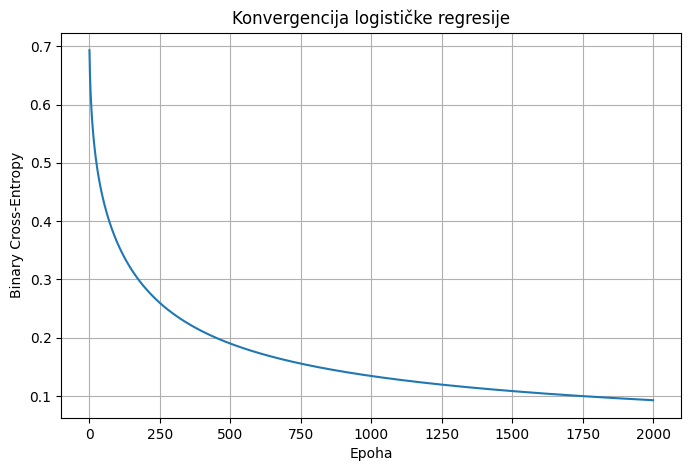

In [470]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_logistic)
plt.xlabel("Epoha")
plt.ylabel("Binary Cross-Entropy")
plt.title("Konvergencija logističke regresije")
plt.grid(True)
plt.show()

In [471]:
theta_logistic, loss_history_logistic = gradient_descent(
    features_cls_final,
    target_cls,
    predict_function=predict_logistic,
    loss_function=binary_cross_entropy,
    gradient_function=compute_gradient_logistic,
    learning_rate=0.01,
    epochs=2000
)

In [474]:
@widgets.interact(
    learning_rate = widgets.FloatSlider(value=0.01, min=0.0001, max=0.3,  step=0.0001, readout_format='.4f'),
    epochs        = widgets.IntSlider  (value=2000, min=10,    max=3000, step=10)
)
def plot_bce(learning_rate, epochs):
    _, loss_history = gradient_descent(
        features_cls_final,
        target_cls,
        predict_function=predict_logistic,
        loss_function=binary_cross_entropy,
        gradient_function=compute_gradient_logistic,
        learning_rate=learning_rate,
        epochs=epochs
    )

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel("Epoha")
    plt.ylabel("Binary cross-entropy")
    plt.title(f"Learning rate={learning_rate} | Epohe={epochs}")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='learning_rate', max=0.3, min=0.0001, readout_format…

### Pretvaranje verovatnoća u klase

In [475]:
final_probabilities = predict_logistic(features_cls_final, theta_logistic)
final_predictions = (final_probabilities >= 0.5).astype(int)

In [476]:
print(final_predictions[:10])

[0 0 0 0 1 0 0 0 0 0]


In [478]:
accuracy = np.mean(final_predictions == target_cls)
accuracy

np.float64(0.9876093294460642)

### Odgovori na pitanja

### Odgovori na pitanja

**Pitanje:** *Objasnite koncept logističke funkcije (sigmoid) i kako ona mapira ulaze u verovatnoće.*

**Odgovor:** *Logistička funkcija (sigmoid) pretvara linearni izlaz modela u vrednost između 0 i 1, čime omogućava interpretaciju rezultata kao verovatnoće pripadnosti određenoj klasi.*

*Sigmoid funkcija ima oblik:*

$$sigma(z)=\frac{1}{1+e^{-z}}$$

*gde je $z = X\theta$.*

*Kada je vrednost $z$ velika i pozitivna, izlaz sigmoid funkcije približava se vrednosti 1, dok se za velike negativne vrednosti približava 0.*

*Na taj način logistička regresija omogućava binarnu klasifikaciju korišćenjem praga od 0.5.*


---


**Pitanje:** *Kako regularizacija (L1 ili L2) utiče na treniranje logističke regresije?*

**Odgovor:** *Regularizacija se koristi da bi se sprečilo prekomerno prilagođavanje modela (overfitting), naročito kada broj karakteristika raste usled polinomske transformacije.*

*L2 regularizacija dodaje kaznu proporcionalnu kvadratu težina modela, čime se velike vrednosti parametara smanjuju i model postaje stabilniji.*

*L1 regularizacija dodaje kaznu proporcionalnu apsolutnim vrednostima težina i može dovesti do toga da neke težine postanu tačno nula, čime se vrši implicitna selekcija karakteristika.*

*U ovom projektu regularizacija nije eksplicitno implementirana, ali bi bila korisna kod većih i složenijih modela.*


---


**Pitanje:** *Koji izazovi se javljaju pri korišćenju polinomskih karakteristika u klasifikaciji i kako ih možete rešiti?*

**Odgovor:** *Polinomske karakteristike povećavaju broj ulaznih atributa, što model čini fleksibilnijim, ali istovremeno povećava složenost modela.*

*Glavni izazovi su:*

* *povećan broj karakteristika*
* *sporije treniranje modela*
* *veći rizik od overfitting-a*

*Ovi problemi se mogu ublažiti standardizacijom podataka, izborom odgovarajućeg stepena polinoma i regularizacijom modela.*

*U ovom projektu polynomial degree 3 omogućio je modelu da uspešno nauči složenije granice između klasa i postigne nisku vrednost binary cross-entropy funkcije greške.*